In [63]:
import pandas as pd

# Use the relative path if the file is in the same folder
df = pd.read_csv('healthcare_analytics_patient_flow_data.csv')

# View the first few rows
print(df.head())


    Patient Id Patient Admission Date Patient Admission Time        Merged  \
0  780-96-6113               9/9/2024             9:25:00 AM     W. Breede   
1  714-35-6722               9/9/2024             4:42:00 PM   Y. Baldetti   
2  571-85-3714               9/9/2024            12:14:00 AM    M. Semerad   
3  404-43-9499               9/9/2024             8:33:00 PM    K. Blaydes   
4  552-51-5855               9/9/2024             7:25:00 PM  F. Dickerson   

  Patient Gender  Patient Age      Patient Race Department Referral  \
0         Female           63  African American                 NaN   
1           Male           31             Asian         Orthopedics   
2           Male           75             White    General Practice   
3           Male           79  African American    General Practice   
4         Female           24  African American                 NaN   

  Patient Admission Flag  Patient Satisfaction Score  Patient Waittime  
0          Not Admission       

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient Admission Time      9216 non-null   object 
 3   Merged                      9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   object 
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 792.1+ KB


In [65]:
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient Admission Time           0
Merged                           0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
dtype: int64

In [66]:
df.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


In [67]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [68]:
#dropping the columns that are not needed for analysis
df = df.drop(columns=["Merged", "Patient Id"])

In [69]:
#df.head()

In [70]:
#replace the null values in the "Department Referral" column with "General/None"
df["Department Referral"] = df["Department Referral"].fillna("General/None")
df.head()

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,9/9/2024,9:25:00 AM,Female,63,African American,General/None,Not Admission,5.0,32
1,9/9/2024,4:42:00 PM,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,9/9/2024,12:14:00 AM,Male,75,White,General Practice,Not Admission,NaN,16
3,9/9/2024,8:33:00 PM,Male,79,African American,General Practice,Admission,NaN,38
4,9/9/2024,7:25:00 PM,Female,24,African American,General/None,Admission,NaN,36


In [71]:
# Now, let's filter the dataset to include only rows where the "Patient Satisfaction Score" is not null
satisfaction_df = df[df["Patient Satisfaction Score"].notnull()]
satisfaction_df.head()  

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,9/9/2024,9:25:00 AM,Female,63,African American,General/None,Not Admission,5.0,32
9,9/9/2024,1:14:00 PM,Female,25,African American,General Practice,Admission,6.0,14
12,9/9/2024,12:34:00 PM,Female,51,Two or More Races,General/None,Admission,7.0,35
14,9/9/2024,10:47:00 AM,Female,33,Native American/Alaska Native,General/None,Not Admission,2.0,42
25,9/9/2023,12:28:00 PM,Female,17,African American,General/None,Not Admission,3.0,37


In [72]:
#reformatting the "Patient Admission Time" column to a datetime format
df["Patient Admission Time"] = pd.to_datetime(
    df["Patient Admission Time"],
    format="%I:%M:%S %p"
).dt.time
df.head()

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,9/9/2024,09:25:00,Female,63,African American,General/None,Not Admission,5.0,32
1,9/9/2024,16:42:00,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,9/9/2024,00:14:00,Male,75,White,General Practice,Not Admission,NaN,16
3,9/9/2024,20:33:00,Male,79,African American,General Practice,Admission,NaN,38
4,9/9/2024,19:25:00,Female,24,African American,General/None,Admission,NaN,36


In [73]:
df = df.drop_duplicates()

In [74]:
#impossible values for "Patient Age" are filtered out
df = df[(df["Patient Age"] >= 0) &
        (df["Patient Age"] <= 100)]

In [75]:
#impossible values for "Patient Waittime" are filtered out
df = df[(df["Patient Waittime"] >= 0) &
        (df["Patient Waittime"] <= 1000)]

In [76]:
#ignore typos
df["Patient Gender"] = (
    df["Patient Gender"]
    .str.strip()
    .str.title()
)

df["Department Referral"] = (
    df["Department Referral"]
    .str.strip()
    .str.title()
)

In [77]:
df["Hour"] = pd.to_datetime(
    df["Patient Admission Time"].astype(str)
).dt.hour

/var/folders/ng/r41nld9s6gv61qbxnkw8_vg80000gn/T/ipykernel_23903/3626022239.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(


In [78]:
df["Patient Admission Date"] = (
    df["Patient Admission Date"]
    .astype(str)
)

df["Patient Admission Date"] = pd.to_datetime(
    df["Patient Admission Date"],
    errors="coerce"
)

df["DayOfWeek"] = (
    df["Patient Admission Date"]
    .dt.day_name()
)

In [79]:
df["Month"] = (
    df["Patient Admission Date"]
    .dt.month_name()
)
df.head()

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Hour,DayOfWeek,Month
0,2024-09-09,09:25:00,Female,63,African American,General/None,Not Admission,5.0,32,9,Monday,September
1,2024-09-09,16:42:00,Male,31,Asian,Orthopedics,Not Admission,NaN,22,16,Monday,September
2,2024-09-09,00:14:00,Male,75,White,General Practice,Not Admission,NaN,16,0,Monday,September
3,2024-09-09,20:33:00,Male,79,African American,General Practice,Admission,NaN,38,20,Monday,September
4,2024-09-09,19:25:00,Female,24,African American,General/None,Admission,NaN,36,19,Monday,September


In [80]:
df["Weekend"] = df["DayOfWeek"].isin(
    ["Saturday", "Sunday"]
)

In [81]:
bins = [0, 17, 34, 49, 64, 100]
labels = ["0-17", "18-34", "35-49", "50-64", "65+"]

df["AgeGroup"] = pd.cut(
    df["Patient Age"],
    bins=bins,
    labels=labels
)

In [82]:
df.head()

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Hour,DayOfWeek,Month,Weekend,AgeGroup
0,2024-09-09,09:25:00,Female,63,African American,General/None,Not Admission,5.0,32,9,Monday,September,False,50-64
1,2024-09-09,16:42:00,Male,31,Asian,Orthopedics,Not Admission,NaN,22,16,Monday,September,False,18-34
2,2024-09-09,00:14:00,Male,75,White,General Practice,Not Admission,NaN,16,0,Monday,September,False,65+
3,2024-09-09,20:33:00,Male,79,African American,General Practice,Admission,NaN,38,20,Monday,September,False,65+
4,2024-09-09,19:25:00,Female,24,African American,General/None,Admission,NaN,36,19,Monday,September,False,18-34


In [83]:
# Create bins for "Patient Waittime"
wait_bins = [0, 15, 30, 60, 120, 1000]
wait_labels = [
    "0-15",
    "16-30",
    "31-60",
    "61-120",
    "120+"
]
#WHAT DETERMINES THE WAITTIME???
# Assign wait time groups based on the defined bins and labels
df["WaitGroup"] = pd.cut(
    df["Patient Waittime"],
    bins=wait_bins,
    labels=wait_labels
)

In [84]:
df["AdmissionBinary"] = df[
    "Patient Admission Flag"
].map({
    "Admission": 1,
    "Not Admission": 0
})

In [85]:
df.head()

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Hour,DayOfWeek,Month,Weekend,AgeGroup,WaitGroup,AdmissionBinary
0,2024-09-09,09:25:00,Female,63,African American,General/None,Not Admission,5.0,32,9,Monday,September,False,50-64,31-60,0
1,2024-09-09,16:42:00,Male,31,Asian,Orthopedics,Not Admission,NaN,22,16,Monday,September,False,18-34,16-30,0
2,2024-09-09,00:14:00,Male,75,White,General Practice,Not Admission,NaN,16,0,Monday,September,False,65+,16-30,0
3,2024-09-09,20:33:00,Male,79,African American,General Practice,Admission,NaN,38,20,Monday,September,False,65+,31-60,1
4,2024-09-09,19:25:00,Female,24,African American,General/None,Admission,NaN,36,19,Monday,September,False,18-34,31-60,1


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Patient Admission Date      3613 non-null   datetime64[ns]
 1   Patient Admission Time      9216 non-null   object        
 2   Patient Gender              9216 non-null   object        
 3   Patient Age                 9216 non-null   int64         
 4   Patient Race                9216 non-null   object        
 5   Department Referral         9216 non-null   object        
 6   Patient Admission Flag      9216 non-null   object        
 7   Patient Satisfaction Score  2517 non-null   float64       
 8   Patient Waittime            9216 non-null   int64         
 9   Hour                        9216 non-null   int32         
 10  DayOfWeek                   3613 non-null   object        
 11  Month                       3613 non-null   object      

In [87]:
df.isnull().sum()

Patient Admission Date        5603
Patient Admission Time           0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral              0
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Hour                             0
DayOfWeek                     5603
Month                         5603
Weekend                          0
AgeGroup                         0
WaitGroup                        0
AdmissionBinary                  0
dtype: int64

In [88]:
df.describe()

,Patient Admission Date,Patient Age,Patient Satisfaction Score,Patient Waittime,Hour,AdmissionBinary
count,3613,9216.000000,2517.000000,9216.000000,9216.000000,9216.000000
mean,2024-01-03 12:16:32.416274688,39.855143,4.992054,35.259874,11.486328,0.500434
min,2023-01-04 00:00:00,1.000000,0.000000,10.000000,0.000000,0.000000
25%,2023-07-08 00:00:00,20.000000,2.000000,23.000000,5.000000,0.000000
50%,2024-01-08 00:00:00,39.000000,5.000000,35.000000,11.000000,1.000000
75%,2024-07-05 00:00:00,60.000000,8.000000,48.000000,18.000000,1.000000
max,2024-12-10 00:00:00,79.000000,10.000000,60.000000,23.000000,1.000000
std,NaN,22.755125,3.138043,14.735323,6.955110,0.500027


In [89]:
satisfaction_df.isnull().sum()

Patient Admission Date        0
Patient Admission Time        0
Patient Gender                0
Patient Age                   0
Patient Race                  0
Department Referral           0
Patient Admission Flag        0
Patient Satisfaction Score    0
Patient Waittime              0
dtype: int64

In [90]:
df.to_csv(
    "hospital_data_cleaned.csv",
    index=False
)

Patient Volume

In [91]:
hourly_volume = df.groupby("Hour").size()

print(hourly_volume)

Hour
0     406
1     372
2     376
3     385
4     384
5     393
6     375
7     415
8     386
9     388
10    349
11    403
12    366
13    410
14    368
15    394
16    378
17    359
18    370
19    383
20    372
21    376
22    372
23    436
dtype: int64


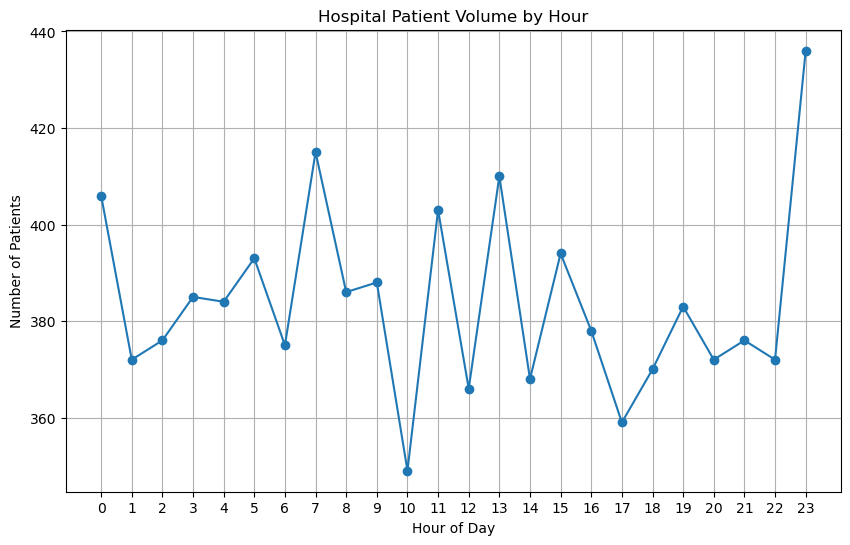

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(hourly_volume.index,
         hourly_volume.values,
         marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Patients")
plt.title("Hospital Patient Volume by Hour")

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

Peak hours 0, 23, 7, 11, and 13 i.e. midnight, 11pm, 7am, 11am, and 1 pm.
The least number of patients is 10am and 7pm.  

In [93]:
monthly_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_volume = df.groupby("Month").size().reindex(monthly_order)

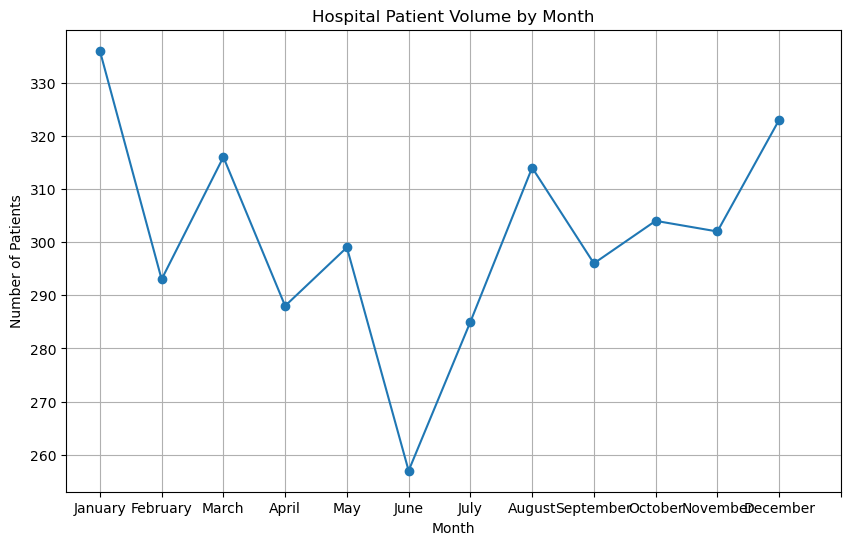

In [94]:
plt.figure(figsize=(10,6))

plt.plot(monthly_volume.index,
         monthly_volume.values,
         marker='o')

plt.xlabel("Month")
plt.ylabel("Number of Patients")
plt.title("Hospital Patient Volume by Month")

plt.xticks(range(0,13))

plt.grid(True)

plt.show()

Peak months are December, January, and March. The lowest months are June (REALLY low). 

In [95]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_volume = (
    df.groupby("DayOfWeek")
    .size()
    .reindex(day_order)
)

print(daily_volume)

DayOfWeek
Monday       543
Tuesday      520
Wednesday    549
Thursday     474
Friday       484
Saturday     515
Sunday       528
dtype: int64


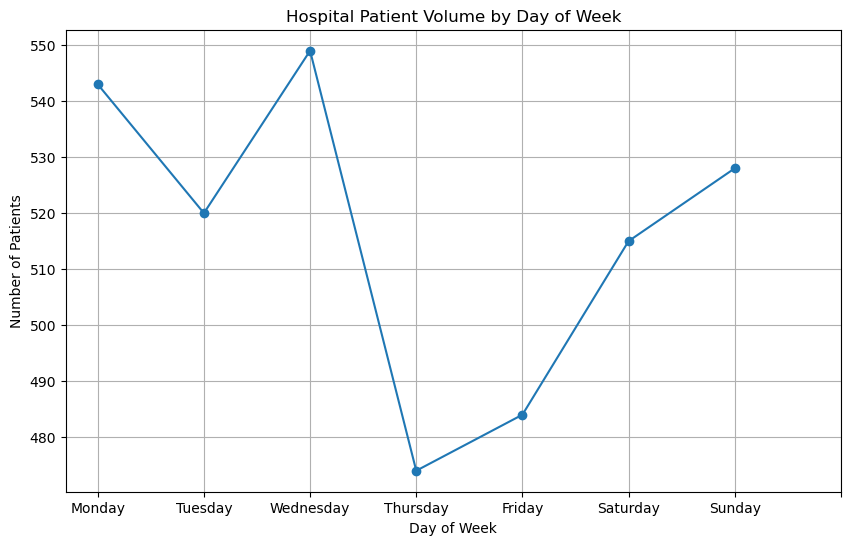

In [96]:
plt.figure(figsize=(10,6))

plt.plot(daily_volume.index,
         daily_volume.values,
         marker='o')

plt.xlabel("Day of Week")
plt.ylabel("Number of Patients")
plt.title("Hospital Patient Volume by Day of Week")

plt.xticks(range(0,8))

plt.grid(True)

plt.show()

Peak Days are Monday, Wednesday. Cases increase from Friday through Sunday. Lowest is Thursday

In [97]:
df.shape[0]

9216

There are 9216 encounters in this dataset after cleaning

Wait Time

In [98]:
df.head()

,Patient Admission Date,Patient Admission Time,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Hour,DayOfWeek,Month,Weekend,AgeGroup,WaitGroup,AdmissionBinary
0,2024-09-09,09:25:00,Female,63,African American,General/None,Not Admission,5.0,32,9,Monday,September,False,50-64,31-60,0
1,2024-09-09,16:42:00,Male,31,Asian,Orthopedics,Not Admission,NaN,22,16,Monday,September,False,18-34,16-30,0
2,2024-09-09,00:14:00,Male,75,White,General Practice,Not Admission,NaN,16,0,Monday,September,False,65+,16-30,0
3,2024-09-09,20:33:00,Male,79,African American,General Practice,Admission,NaN,38,20,Monday,September,False,65+,31-60,1
4,2024-09-09,19:25:00,Female,24,African American,General/None,Admission,NaN,36,19,Monday,September,False,18-34,31-60,1


In [99]:
avg_wait_time = df["Patient Waittime"].mean()
print(f"Average Wait Time: {avg_wait_time:.2f} minutes")

Average Wait Time: 35.26 minutes


In [100]:
#determine which department has the highest wait time
dept_wait_time = df.groupby("Department Referral")["Patient Waittime"].mean().sort_values(ascending=False)
print(dept_wait_time)

Department Referral
Neurology           36.803109
Physiotherapy       36.565217
Gastroenterology    35.831461
Cardiology          35.354839
General/None        35.293148
Orthopedics         34.982915
General Practice    34.912500
Renal               34.697674
Name: Patient Waittime, dtype: float64


The department with the highest wait time is Neurology with an average wait time of 36.803 minutes.

In [101]:
#determine if admitted patients have a higher average wait time than non-admitted patients
admitted_wait_time = df[df["AdmissionBinary"] == 1]["Patient Waittime"].mean()
non_admitted_wait_time = df[df["AdmissionBinary"] == 0]["Patient Waittime"].mean()
print(f"Average Wait Time for Admitted Patients: {admitted_wait_time:.2f} minutes")
print(f"Average Wait Time for Non-Admitted Patients: {non_admitted_wait_time:.2f} minutes")


Average Wait Time for Admitted Patients: 34.97 minutes
Average Wait Time for Non-Admitted Patients: 35.55 minutes


Non-Admitted patients wait an average of 35.55 minutes while admitted patients wait an average of 34.97 minutes.

In [102]:
#determine which hours have the highest wait times
hourly_wait_time = df.groupby("Hour")["Patient Waittime"].mean().sort_values(ascending=False)
print(hourly_wait_time)

Hour
3     37.218182
22    36.602151
11    36.461538
5     36.386768
9     36.360825
23    36.250000
10    35.616046
13    35.560976
2     35.364362
8     35.321244
7     35.262651
6     35.133333
4     34.929688
20    34.927419
21    34.882979
18    34.778378
14    34.741848
17    34.693593
16    34.584656
15    34.385787
19    34.266319
0     34.251232
1     34.064516
12    33.879781
Name: Patient Waittime, dtype: float64


3am has the highest wait times. Noon has the lowest wait times.

Admissions

In [103]:
#determine the percentage of patients admitted vs not admitted
admission_counts = df["AdmissionBinary"].value_counts()
admission_percentage = admission_counts / df.shape[0] * 100
print(admission_percentage)

AdmissionBinary
1    50.043403
0    49.956597
Name: count, dtype: float64


50.04 percent admitted vs 49.95 percent non-admitted.

In [104]:
#determine which departments have the highest admission rates
dept_admission_rate = (
    df.groupby("Department Referral")["AdmissionBinary"]
    .mean()
    .sort_values(ascending=False)
)

#converting to percentages
dept_admission_rate_percentage = dept_admission_rate * 100
print(dept_admission_rate_percentage)

Department Referral
Renal               53.488372
General/None        50.666667
Neurology           50.259067
Orthopedics         50.050251
Gastroenterology    50.000000
Physiotherapy       49.637681
Cardiology          49.193548
General Practice    48.206522
Name: AdmissionBinary, dtype: float64


Renal has the highest percentage of admission rates.

In [105]:
#determine which hours have the highest admission rates
hourly_admission_rate = (
    df.groupby("Hour")["AdmissionBinary"]
    .mean()
    .sort_values(ascending=False)
)
hourly_admission_rate_percentage = hourly_admission_rate * 100
print(hourly_admission_rate_percentage)

Hour
19    54.046997
20    53.763441
13    53.658537
1     53.494624
14    52.445652
11    52.357320
23    51.834862
17    51.532033
9     50.773196
8     50.518135
12    50.273224
16    50.264550
4     50.000000
7     49.879518
22    49.731183
5     49.363868
21    48.670213
0     48.522167
15    47.969543
6     47.733333
2     47.606383
3     45.974026
10    45.558739
18    44.324324
Name: AdmissionBinary, dtype: float64


Satisfaction

In [106]:
#determine the average satsifaction score
avg_satisfaction_score = satisfaction_df["Patient Satisfaction Score"].mean()
print(f"Average Patient Satisfaction Score: {avg_satisfaction_score:.2f}")

Average Patient Satisfaction Score: 4.99


In [107]:
#determine average satsifaction score by department
dept_satisfaction_score = (
    satisfaction_df.groupby("Department Referral")["Patient Satisfaction Score"]
    .mean()
    .sort_values(ascending=False)
)
print(dept_satisfaction_score)

Department Referral
Gastroenterology    5.796296
Neurology           5.283019
Cardiology          5.140845
General Practice    5.061630
Physiotherapy       4.987952
General/None        4.953472
Orthopedics         4.858621
Renal               4.565217
Name: Patient Satisfaction Score, dtype: float64


In [111]:
#determine if satisfaction decreases as wait time increases
wait_satisfaction = satisfaction_df.groupby("Patient Waittime")["Patient Satisfaction Score"].mean().sort_values(ascending=False)
print(wait_satisfaction)    

Patient Waittime
34    5.977778
11    5.955556
12    5.823529
54    5.761905
48    5.625000
42    5.553846
47    5.549020
18    5.413043
25    5.404762
22    5.367347
59    5.351852
58    5.271186
15    5.234375
14    5.224138
41    5.181818
19    5.152174
27    5.111111
53    5.100000
36    5.072727
45    5.061538
17    5.045455
13    5.000000
10    4.981132
33    4.978261
28    4.977778
57    4.931818
37    4.925000
23    4.902439
51    4.897959
31    4.880952
46    4.870968
21    4.868421
49    4.840909
29    4.818182
52    4.812500
38    4.785714
16    4.769231
44    4.720000
32    4.698113
26    4.687500
50    4.640000
20    4.622222
43    4.600000
55    4.577778
35    4.549020
60    4.545455
56    4.516667
24    4.354167
39    4.277778
40    4.272727
30    4.120690
Name: Patient Satisfaction Score, dtype: float64


I don't believe patient satisfaction decreases as patient wait time increases.

In [112]:
#determine which departments has the lowest satisfaction scores
dept_lowest_satisfaction = (
    satisfaction_df.groupby("Department Referral")["Patient Satisfaction Score"]
    .mean()
    .sort_values(ascending=True)
)
print(dept_lowest_satisfaction)

Department Referral
Renal               4.565217
Orthopedics         4.858621
General/None        4.953472
Physiotherapy       4.987952
General Practice    5.061630
Cardiology          5.140845
Neurology           5.283019
Gastroenterology    5.796296
Name: Patient Satisfaction Score, dtype: float64


Renal has the lowest satisfaction.

In [113]:
#correlation between wait time and satisfaction score
correlation = satisfaction_df["Patient Waittime"].corr(satisfaction_df["Patient Satisfaction Score"])
print(f"Correlation between Wait Time and Satisfaction Score: {correlation:.2f}")

Correlation between Wait Time and Satisfaction Score: -0.02
